# 1M Confirmation Candle Analysis

Analyzes trade alignment with 1H (higher timeframe) direction and PD (Premium/Discount) zones.

In [1]:
import sys
sys.path.insert(0, '../strategies/15LS1CC')

from IPython.display import display, HTML

# Enable automatic module reloading
%load_ext autoreload
%autoreload 2

from utils.confirmation_candle import (
    load_data, display_analysis_strategies,
    display_analysis_sl, display_analysis_pullback,
    display_analysis_sl_pb_crosstab,
    display_analysis_sl_pb_distribution,
    display_analysis_sl_pb_buffer_impact,
    display_analysis_tp,
    display_r_histogram_combined,
    display_weekday,
)

# Load data
df = load_data()

# Disable scrolling
HTML('<style>.jp-OutputArea { max-height: none !important; }</style>')

In [2]:
# Weekday statistics show that no days are very bad nor good
display_weekday(df)

Day,Trades,Regular,With 2 pips buffer
Monday,116,27W - 89L (23.3%),44W - 72L (37.9%)
Tuesday,144,33W - 111L (22.9%),55W - 89L (38.2%)
Wednesday,136,35W - 101L (25.7%),57W - 79L (41.9%)
Thursday,102,23W - 79L (22.5%),37W - 65L (36.3%)
Friday,103,25W - 78L (24.3%),37W - 66L (35.9%)


In [3]:
# SL range statistics show that almost all trades are in less than 5 pips SL (makes sense as signal timeframe is 1M)
display_analysis_sl(df)

SL Range,Trades,Regular,With 2 pips buffer
< 5,535,119W - 416L (22.2%),199W - 336L (37.2%)
5+,67,24W - 43L (35.8%),31W - 36L (46.3%)


In [4]:
# TP range statistics shows that 80% of the trades are <35 pips away
display_analysis_tp(df)

TP Range,Trades
0-35,236 of 298
35+,62 of 298


In [5]:
# R value distribution shows that 94% of trades reach 2R, then 81% reach 3R, 68% reach 4R and so on.
display_r_histogram_combined(df)

In [6]:
# Pullback range statistics (0-3, 3-5, 5-10, 10+)
display_analysis_pullback(df)

Pullback Range,Trades,Regular,With 2 pips buffer
0-3,406,122W - 284L (30.0%),178W - 228L (43.8%)
3-5,107,12W - 95L (11.2%),31W - 76L (29.0%)
5-10,77,9W - 68L (11.7%),19W - 58L (24.7%)
10+,12,0W - 12L (0.0%),2W - 10L (16.7%)


In [7]:
# SL x Pullback cross-tab: where does the mass of (SL, Pullback) pairs sit?
display_analysis_sl_pb_crosstab(df)

SL Range,0-1,1-2,2-3,3-5,5-10,10+,Total
0-2,102 (33%),147 (48%),24 (8%),26 (8%),9 (3%),0 (0%),308
2-3,12 (9%),19 (15%),66 (51%),17 (13%),15 (12%),0 (0%),129
3-5,12 (12%),10 (10%),5 (5%),58 (59%),11 (11%),2 (2%),98
5-10,1 (2%),3 (6%),5 (10%),5 (10%),38 (73%),0 (0%),52
10+,0 (0%),0 (0%),0 (0%),1 (7%),4 (27%),10 (67%),15


In [8]:
# Pullback distribution per SL bucket: how big do pullbacks get for each SL size?
display_analysis_sl_pb_distribution(df)

SL Range,Trades,PB Mean,PB Median,PB p75,PB p90,PB Max,PB/SL Median,% PB ≥ SL
0-2,308,1.60,1.30,1.80,3.40,9.20,1.00,83%
2-3,129,2.74,2.40,2.90,5.32,9.00,1.00,72%
3-5,98,3.53,3.50,4.38,5.66,11.30,1.00,66%
5-10,52,5.86,6.15,7.83,8.86,9.70,1.00,63%
10+,15,10.69,11.80,13.25,13.72,17.90,1.00,67%


In [9]:
# Buffer impact per SL bucket: how often does +1/+2/+3 pip buffer flip a loss into a win?
display_analysis_sl_pb_buffer_impact(df)

SL Range,Trades,Loss Rate,+1 Saves,+2 Saves,+3 Saves
0-2,308,83%,65%,71%,77%
2-3,129,72%,49%,57%,64%
3-5,98,66%,53%,58%,60%
5-10,52,63%,50%,56%,62%
10+,15,67%,60%,60%,60%


Strategy,Buffer,RRR,Trades,Notation,Win Rate
All Trades,+0,1:1,602,143W – 459L,23.8%
All Trades,+1,1:1,602,191W – 411L,31.7%
All Trades,+2,1:1,602,225W – 377L,37.4%
All Trades,+3,1:1,602,253W – 349L,42.0%
All Trades,+4,1:1,602,265W – 337L,44.0%
All Trades,+5,1:1,602,266W – 336L,44.2%
All Trades,+0,1:2,602,134W – 468L,22.3%
All Trades,+1,1:2,602,175W – 427L,29.1%
All Trades,+2,1:2,602,190W – 412L,31.6%
All Trades,+3,1:2,602,194W – 408L,32.2%


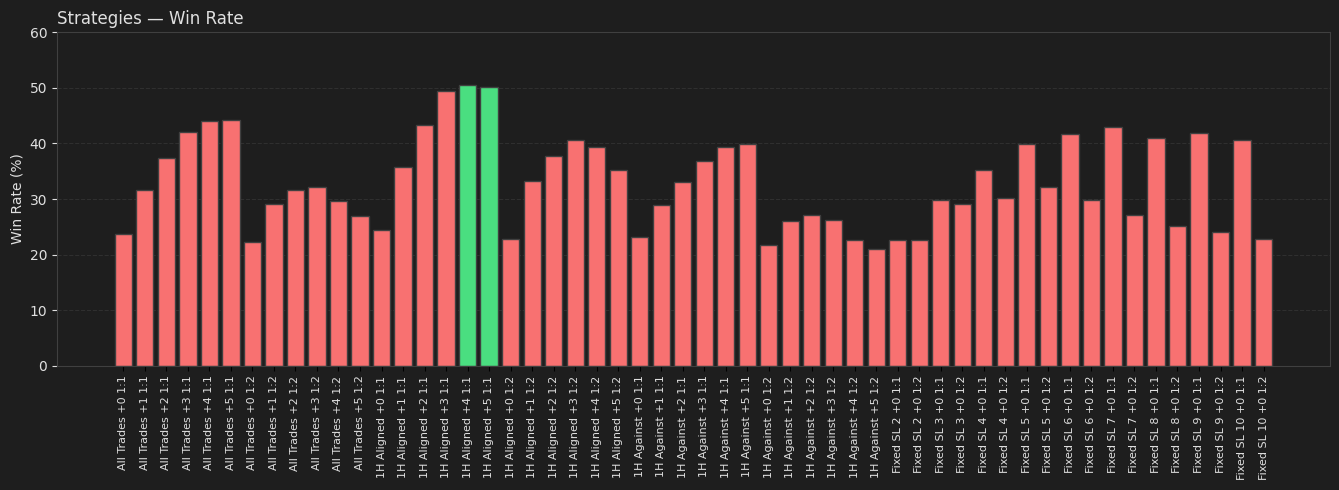

In [10]:
# Strategies: All Trades + 1H Aligned/Against across SL buffers
display_analysis_strategies(df)